# Переобучение и выбор модели

Лекция 2 · Курс «Машинное обучение», 4 курс

## Недообучение и переобучение

- **Недообучение**: модель слишком простая, ошибка велика и на train, и на test
- **Переобучение**: модель запомнила шум, ошибка на train мала, на test — велика

Задача — найти баланс сложности.

## Разложение ошибки

$$\mathbb{E}\bigl[(y - a(x))^2\bigr] =
  \underbrace{\text{bias}^2}_{\text{смещение}} +
  \underbrace{\text{variance}}_{\text{разброс}} +
  \underbrace{\sigma^2}_{\text{шум}}$$

- Простые модели: большое смещение, малый разброс
- Сложные модели: малое смещение, большой разброс

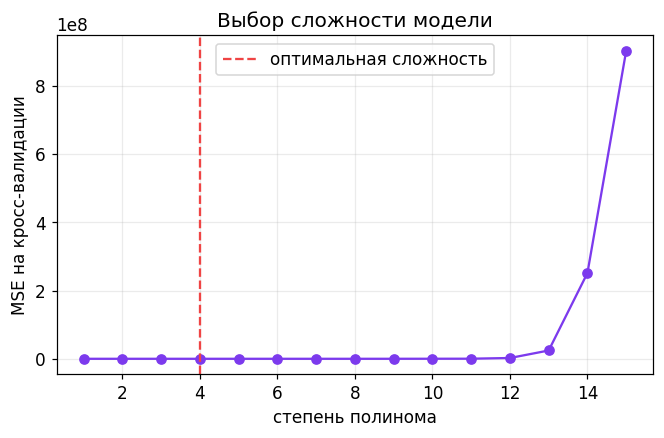

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({
    "figure.figsize": (7, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
rng = np.random.default_rng(42)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

X = np.sort(rng.uniform(-3, 3, 80)).reshape(-1, 1)
y = np.sin(X).ravel() + rng.normal(0, 0.35, size=80)

degrees = range(1, 16)
scores = [-cross_val_score(make_pipeline(PolynomialFeatures(d), LinearRegression()),
                           X, y, cv=5, scoring="neg_mean_squared_error").mean()
          for d in degrees]

plt.plot(list(degrees), scores, marker="o", color="#7c3aed")
plt.axvline(list(degrees)[int(np.argmin(scores))], ls="--", color="#ef4444",
            label="оптимальная сложность")
plt.xlabel("степень полинома"); plt.ylabel("MSE на кросс-валидации")
plt.title("Выбор сложности модели")
plt.legend()
plt.show()

## Кросс-валидация

- **K-fold**: выборка делится на $K$ частей, каждая по очереди — валидационная
- **Stratified K-fold**: сохраняет баланс классов
- **Leave-one-out**: $K = \ell$, дорого, но почти несмещённо

Итоговая оценка — среднее по фолдам.

## Практические правила

1. Фиксируйте `random_state` — иначе результаты невоспроизводимы
2. Масштабирование и отбор признаков делайте **внутри** пайплайна
3. Тестовую выборку трогайте один раз
4. Сравнивайте с простым baseline: константа, `DummyClassifier`